# H_local v4 — Indice de stress hydrique territorial

**Notebook pedagogique complet avec pipeline integre et tests**

## Que fait ce notebook ?

Ce notebook construit, etape par etape, un indice composite **H_local** qui evalue le stress hydrique territorial pour des sites candidats a l'implantation de centres de donnees en France.

Chaque section :
1. Explique la formule mathematique
2. Implemente le code
3. Teste le resultat

Le score sort entre **0 (territoire favorable)** et **1 (territoire tres contraint)**.

## Architecture du modele en 3 couches

```
Couche 1 - Climatologique     : SPEI (anomalie de secheresse)
Couche 2 - Structurelle       : BWS, Aridite, GWS (indicateurs Aqueduct/ERA5)
Couche 3 - Decisionnelle      : AHP (poids) + agregation + ponderation dynamique
```

## Formule finale (v2.5a)

$$H_{\text{local}}(x,t) = \beta(t) \cdot S_{\text{struct}}(x) + (1 - \beta(t)) \cdot S_{\text{conj}}(x,t)$$

$$\beta(t) = \beta_0 \cdot (1 - S_{\text{conj}}(x,t)), \quad \beta_0 = 0{,}70$$

$$S_{\text{struct}}(x) = \sum_i w_i \cdot x_i \quad \text{(arithmetique ponderee, poids AHP)}$$

$$S_{\text{conj}}(x,t) = \frac{d_3 e^{\tau d_3} + d_{12} e^{\tau d_{12}}}{e^{\tau d_3} + e^{\tau d_{12}}}, \quad \tau = 5$$

$$f(\text{SPEI}) = \frac{-\text{SPEI}}{c + |\text{SPEI}|}, \quad c = 2$$

## Upgrades v4 par rapport a v3

1. Pipeline integre (un seul notebook au lieu de cellules eparpillees)
2. Test d'ablation (Aridite vs GWS)
3. Bootstrap AHP (intervalles de confiance sur les poids)
4. Validation multivariee (correlation, ACP, VIF)
5. Benchmark canonique (WSI Pfister 2009)
6. Documentation pedagogique inline

## References cles

- Saaty (1980) — AHP
- Vicente-Serrano et al. (2010) — SPEI
- Nardo et al. (2005) — OECD/JRC composite indicators
- Pfister et al. (2009) — WSI canonique
- Saltelli et al. (2010) — Sobol global sensitivity

---
## 1. Setup et configuration

On charge les bibliotheques et on definit les chemins, sites de validation, et parametres du modele.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import rasterio
from scipy import stats
from pathlib import Path
from itertools import product
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import seaborn as sns

print("Bibliotheques chargees")

Bibliotheques chargees


In [2]:
# --- Chemins ---
BASE = Path("../water_model/data")
RAW  = BASE / "raw"
AQUEDUCT_BWS = RAW / "aqueduct" / "bws_raw.tif"
AQUEDUCT_GWS = RAW / "aqueduct" / "gws_raw.tif"
ERA5_FULL    = RAW / "era5"     / "era5_monthly_1981_2022.nc"

# --- Sites de validation (8 sites contrastes France metropolitaine) ---
SITES = {
    "Paris-Saclay":  (48.73,  2.17),
    "Lyon":          (45.76,  4.83),
    "Marseille":     (43.30,  5.37),
    "Strasbourg":    (48.57,  7.75),
    "Brest":         (48.39, -4.49),
    "Rennes":        (48.11, -1.68),
    "Bordeaux":      (44.84, -0.58),
    "Montpellier":   (43.61,  3.88),
}

# --- Parametres modele ---
BWS_MAX_FR  = 0.60       # max France pour BWS (renormalisation locale)
GWS_MAX_FR  = 0.15       # max France pour GWS
C_ASYM      = 2.0        # constante asymptotique f(SPEI), figee semantiquement
TAU_BOLTZ   = 5.0        # temperature operateur Boltzmann
BETA_0      = 0.70       # poids structurel de base
SPEI_BASELINE = (1981, 2010)

# --- Poids AHP (CR = 0.0015), renormalises sur 3 indicateurs (SV non disponible) ---
W_AHP_3 = {
    "bws":     0.532 / 0.902,
    "aridity": 0.185 / 0.902,
    "gws":     0.185 / 0.902,
}

# --- Annees de validation ---
VALIDATION_DATES = [(2015, 7), (2018, 7), (2022, 7)]

# --- Niveaux Propluvia juillet 2022 (1=Vigilance, 4=Crise) ---
PROPLUVIA_2022 = {
    "Marseille": 4, "Montpellier": 3, "Lyon": 4, "Bordeaux": 3,
    "Paris-Saclay": 2, "Strasbourg": 2, "Rennes": 4, "Brest": 1,
}

# Test : verifier que les fichiers sont presents
print("=== Test des chemins ===")
for f in [AQUEDUCT_BWS, AQUEDUCT_GWS, ERA5_FULL]:
    print(f"  {f.name:32s} : {'OK' if f.exists() else 'MANQUANT'}")
print(f"\n{len(SITES)} sites configures, {len(VALIDATION_DATES)} dates de validation")

=== Test des chemins ===
  bws_raw.tif                      : OK
  gws_raw.tif                      : OK
  era5_monthly_1981_2022.nc        : OK

8 sites configures, 3 dates de validation


---
## 2. Couche climatologique : le SPEI

### Objectif

Mesurer **a quel point un site est en secheresse maintenant**, par rapport a sa propre normale historique.

### Formule

**Bilan hydrique mensuel** :
$$D_i = P_i - PET_i$$

ou $P$ = precipitations, $PET$ = evapotranspiration potentielle.

**Cumul sur N mois (3 ou 12)** :
$$D_{\text{acc}}(i, N) = \sum_{j=i-N+1}^{i} D_j$$

**SPEI** = position du cumul dans la distribution log-logistique ajustee sur la baseline 1981-2010, transformee en ecart a la normale standard :
$$\text{SPEI}_N(i) = \Phi^{-1}\left(F_{\text{Fisk}}(D_{\text{acc}}(i, N))\right)$$

### Lecture

| SPEI | Interpretation |
|---|---|
| 0 | normale historique |
| -1 | secheresse moderee |
| -2 | secheresse severe |
| -3 et au-dela | exceptionnel |

### Choix multi-echelle : SPEI-3 et SPEI-12

- **SPEI-3** : choc recent (3 derniers mois)
- **SPEI-12** : secheresse profonde (12 derniers mois)

Reference : Vicente-Serrano et al. (2010), Beguería et al. (2014).

In [3]:
def compute_spei(precip_mm, pet_mm, dates, window=12,
                 baseline_start=SPEI_BASELINE[0],
                 baseline_end=SPEI_BASELINE[1]):
    """SPEI multi-echelle avec ajustement Fisk par mois calendaire."""
    D = precip_mm - pet_mm
    n = len(D)
    D_acc = np.full(n, np.nan)
    for i in range(window - 1, n):
        D_acc[i] = np.sum(D[i - window + 1 : i + 1])

    months = dates.month
    mask_base = (dates.year >= baseline_start) & (dates.year <= baseline_end)

    monthly_params = {}
    for m in range(1, 13):
        mask_m = (months == m) & mask_base & ~np.isnan(D_acc)
        base_m = D_acc[mask_m]
        if len(base_m) < 10:
            monthly_params[m] = None
            continue
        shift_m = -np.min(base_m) + 1.0
        try:
            c, _, scale = stats.fisk.fit(base_m + shift_m, floc=0)
            monthly_params[m] = (c, scale, shift_m)
        except Exception:
            monthly_params[m] = None

    spei = np.full(n, np.nan)
    for i in range(n):
        if np.isnan(D_acc[i]) or monthly_params.get(months[i]) is None:
            continue
        c, scale, shift_m = monthly_params[months[i]]
        prob = stats.fisk.cdf(D_acc[i] + shift_m, c, loc=0, scale=scale)
        prob = np.clip(prob, 1e-6, 1 - 1e-6)
        spei[i] = stats.norm.ppf(prob)

    return spei

print("compute_spei() definie")

compute_spei() definie


### Transformation SPEI -> stress dans [0, 1]

Le SPEI est en ecarts-types (negatif quand sec). Il faut le transformer en stress entre 0 et 1.

**Choix : fonction asymptotique non saturante**

$$f(\text{SPEI}) = \begin{cases} 0 & \text{si } \text{SPEI} \geq 0 \\ \dfrac{-\text{SPEI}}{c + |\text{SPEI}|} & \text{si } \text{SPEI} < 0 \end{cases}, \quad c = 2$$

**Ancrage semantique** : a SPEI = -2 (secheresse moderee selon WMO/McKee 1993), $f = 0{,}5$ (point milieu de l'echelle).

**Avantage** : asymptote a 1 sans la saturer, preserve l'ordre entre sites en crise extreme.

In [4]:
def f_asym(spei, c=C_ASYM):
    """Transfert SPEI -> stress [0, 1)."""
    if np.isnan(spei):
        return np.nan
    if spei >= 0:
        return 0.0
    return float(-spei / (c + abs(spei)))


# Test : valeurs de reference
print("Test de la fonction de transfert :")
for s in [0, -0.5, -1, -1.5, -2, -3, -5]:
    print(f"  f(SPEI = {s:5.1f}) = {f_asym(s):.3f}")

Test de la fonction de transfert :
  f(SPEI =   0.0) = 0.000
  f(SPEI =  -0.5) = 0.200
  f(SPEI =  -1.0) = 0.333
  f(SPEI =  -1.5) = 0.429
  f(SPEI =  -2.0) = 0.500
  f(SPEI =  -3.0) = 0.600
  f(SPEI =  -5.0) = 0.714


### Combinaison multi-echelle : operateur de Boltzmann

Comment combiner $f(\text{SPEI-3})$ et $f(\text{SPEI-12})$ en un seul nombre $S_{\text{conj}}$ ?

**Choix : Boltzmann operator** (Asadi & Littman 2017, ICML).

$$S_{\text{conj}} = \frac{d_3 \cdot e^{\tau d_3} + d_{12} \cdot e^{\tau d_{12}}}{e^{\tau d_3} + e^{\tau d_{12}}}, \quad \tau = 5$$

C'est une **moyenne ponderee exponentielle** :
- Le plus grand des deux signaux pese plus.
- Differentiable partout (utile pour calibration future).

Verifie empiriquement : remplacer Boltzmann par max dur degrade Propluvia de 0.16 → on garde.

In [5]:
def s_conj_boltzmann(d3, d12, tau=TAU_BOLTZ):
    """Combinaison multi-echelle SPEI par operateur de Boltzmann.

    NB : ce n'est PAS le softmax (qui sort un vecteur).
    Sortie scalaire dans [min(d3,d12), max(d3,d12)].
    """
    if np.isnan(d3) and np.isnan(d12):
        return np.nan
    if np.isnan(d3):
        return d12
    if np.isnan(d12):
        return d3
    e3, e12 = np.exp(tau * d3), np.exp(tau * d12)
    return float((d3 * e3 + d12 * e12) / (e3 + e12))


# Test : verifications de coherence
print("Test Boltzmann operator (tau=5):")
print(f"  d3=d12=0.3   -> S_conj = {s_conj_boltzmann(0.3, 0.3):.3f}  (attendu 0.300)")
print(f"  d3=0.3,d12=0 -> S_conj = {s_conj_boltzmann(0.3, 0.0):.3f}  (proche de max=0.30)")
print(f"  d3=0.5,d12=0 -> S_conj = {s_conj_boltzmann(0.5, 0.0):.3f}  (proche de max=0.50)")

Test Boltzmann operator (tau=5):
  d3=d12=0.3   -> S_conj = 0.300  (attendu 0.300)
  d3=0.3,d12=0 -> S_conj = 0.245  (proche de max=0.30)
  d3=0.5,d12=0 -> S_conj = 0.462  (proche de max=0.50)


---
## 3. Couche structurelle : 3 indicateurs

### BWS (Baseline Water Stress)

Ratio prelevements totaux / eau de surface disponible.

$$x_{\text{BWS}} = \text{clip}\left(\frac{\text{BWS}_{\text{raw}}}{0{,}60}, 0, 1\right)$$

Renormalise sur le max France (~0.50, marge 20%) — sinon les sites francais s'ecrasent dans [0, 0.1].

### Aridite (UNEP)

$$AI = \frac{P_{\text{annuel}}}{PET_{\text{annuel}}} \quad \text{(baseline 1981-2010)}$$

$$x_A = \frac{1}{1 + (AI / 0{,}65)^3}$$

Sigmoide centree sur le seuil PNUE sub-humide sec ($AI = 0{,}65$).

### GWS (Groundwater Stress)

Ratio prelevements en nappe / recharge.

$$x_{\text{GWS}} = \text{clip}\left(\frac{\text{GWS}_{\text{raw}}}{0{,}15}, 0, 1\right)$$

In [6]:
def extract_raster_point(path, lat, lon):
    """Extrait la valeur d\'un raster GeoTIFF au point (lat, lon)."""
    if not Path(path).exists():
        return np.nan
    with rasterio.open(path) as src:
        vals = list(src.sample([(lon, lat)]))
        val = float(vals[0][0])
        if src.nodata is not None and val == src.nodata:
            return np.nan
        return val


def compute_aridity(precip_mm, pet_mm, dates, ai_mid=0.65, k=3.0):
    """Aridite UNEP : sigmoide sur le ratio P/PET annuel."""
    mask = (dates.year >= SPEI_BASELINE[0]) & (dates.year <= SPEI_BASELINE[1])
    n_years = SPEI_BASELINE[1] - SPEI_BASELINE[0] + 1
    p_ann = np.sum(precip_mm[mask]) / n_years
    pet_ann = np.sum(pet_mm[mask]) / n_years
    if pet_ann <= 0:
        return 0.0, np.nan
    ai = p_ann / pet_ann
    a_stress = 1.0 / (1.0 + (ai / ai_mid) ** k)
    return float(a_stress), float(ai)


def find_land_gridpoint(lat, lon, ds, threshold=0.60):
    """Detecte les pixels cotiers ERA5 et reroute vers le voisin continental."""
    td = "valid_time" if "valid_time" in ds.dims else "time"
    lats, lons = ds.latitude.values, ds.longitude.values
    i_lat = int(np.argmin(np.abs(lats - lat)))
    i_lon = int(np.argmin(np.abs(lons - lon)))
    times = pd.DatetimeIndex(ds[td].values)
    month_idx = next(k for k in range(len(times)-1, -1, -1) if times[k].month == 7)
    lat_sl = slice(max(0, i_lat-1), min(len(lats), i_lat+2))
    lon_sl = slice(max(0, i_lon-1), min(len(lons), i_lon+2))
    pev_3x3 = ds["pev"].isel({td: month_idx, "latitude": lat_sl, "longitude": lon_sl})
    pet_3x3 = np.maximum(-pev_3x3.values.astype(float), 0.0)
    pet_center = pet_3x3[min(1, i_lat), min(1, i_lon)]
    pet_max = np.max(pet_3x3)
    ratio = pet_center / pet_max if pet_max > 0 else 1.0
    if ratio >= threshold:
        return float(lats[i_lat]), float(lons[i_lon])
    local_lats, local_lons = lats[lat_sl], lons[lon_sl]
    max_pos = np.unravel_index(np.argmax(pet_3x3), pet_3x3.shape)
    return float(local_lats[max_pos[0]]), float(local_lons[max_pos[1]])

print("Fonctions structurelles definies")

Fonctions structurelles definies


---
## 4. Pipeline integre : calcul de H_local pour les 8 sites

On combine maintenant toutes les couches pour calculer **H_local** sur les 8 sites x 3 annees.

In [7]:
def s_struct_arith(x_bws, x_a, x_gws, weights=W_AHP_3):
    """S_struct = moyenne arithmetique ponderee (poids AHP).
    Reference : Nardo et al. (2005) OECD/JRC composite indicators."""
    comps = [(weights["bws"], x_bws),
             (weights["aridity"], x_a),
             (weights["gws"], x_gws)]
    valid = [(w, v) for w, v in comps if not np.isnan(v)]
    if not valid:
        return np.nan
    return sum(w * v for w, v in valid) / sum(w for w, _ in valid)


def assemble_H(s_struct, s_conj, beta_0=BETA_0):
    """Assemblage H_local = beta(t)*S_struct + (1-beta(t))*S_conj.
    beta(t) = beta_0 * (1 - S_conj) — ponderation dynamique."""
    if np.isnan(s_struct) and np.isnan(s_conj):
        return np.nan, np.nan
    if np.isnan(s_struct):
        return float(s_conj), 0.0
    if np.isnan(s_conj):
        return float(s_struct), beta_0
    beta_t = beta_0 * (1.0 - s_conj)
    H = beta_t * s_struct + (1 - beta_t) * s_conj
    return float(np.clip(H, 0, 1)), float(beta_t)

print("Fonctions d\'agregation definies")

Fonctions d'agregation definies


In [8]:
# === Pipeline complet : calcul H_local pour 8 sites x 3 annees ===

ds = xr.open_dataset(ERA5_FULL)
td = "valid_time" if "valid_time" in ds.dims else "time"

# Detection pixels cotiers
print("=== Detection pixels cotiers ===")
coastal_map = {}
for name, (lat, lon) in SITES.items():
    blat, blon = find_land_gridpoint(lat, lon, ds)
    coastal_map[name] = (blat, blon)
    if (blat, blon) != (round(lat*4)/4, round(lon*4)/4):
        print(f"  {name:14s} : COASTAL -> ({blat:.2f}, {blon:.2f})")

# Calcul pipeline complet
rows = []
print("\n=== Calcul H_local pour 8 sites x 3 annees ===")
for name, (lat, lon) in SITES.items():
    bws_raw = extract_raster_point(AQUEDUCT_BWS, lat, lon)
    gws_raw = extract_raster_point(AQUEDUCT_GWS, lat, lon)
    x_bws = float(np.clip(bws_raw / BWS_MAX_FR, 0, 1)) if not np.isnan(bws_raw) else np.nan
    x_gws = float(np.clip(gws_raw / GWS_MAX_FR, 0, 1)) if not np.isnan(gws_raw) else np.nan

    pet_lat, pet_lon = coastal_map[name]
    tp = ds["tp"].sel(latitude=lat, longitude=lon, method="nearest")
    t = pd.DatetimeIndex(tp[td].values)
    dy = t.days_in_month.values.astype(float)
    P = np.maximum(tp.values.astype(float) * dy * 1000, 0)
    pv = ds["pev"].sel(latitude=pet_lat, longitude=pet_lon, method="nearest")
    PET = np.maximum(-pv.values.astype(float) * dy * 1000, 0)

    x_a, ai = compute_aridity(P, PET, t)
    spei12 = compute_spei(P, PET, t, 12)
    spei3  = compute_spei(P, PET, t, 3)

    for year, month in VALIDATION_DATES:
        idx = next((i for i, tt in enumerate(t)
                    if tt.year == year and tt.month == month), None)
        if idx is None:
            continue
        d3, d12 = f_asym(spei3[idx]), f_asym(spei12[idx])
        s_struct = s_struct_arith(x_bws, x_a, x_gws)
        s_conj   = s_conj_boltzmann(d3, d12)
        H, beta_t = assemble_H(s_struct, s_conj)

        rows.append({
            "Site": name, "year": year,
            "x_bws": x_bws, "x_a": x_a, "x_gws": x_gws,
            "AI": ai, "SPEI3": spei3[idx], "SPEI12": spei12[idx],
            "d3": d3, "d12": d12,
            "S_struct": s_struct, "S_conj": s_conj,
            "beta_t": beta_t, "H": H,
        })

ds.close()
df_results = pd.DataFrame(rows)
print(f"\nPipeline OK : {len(df_results)} observations calculees")
df_results[["Site", "year", "S_struct", "S_conj", "beta_t", "H"]].round(3)

=== Detection pixels cotiers ===
  Marseille      : COASTAL -> (43.50, 5.00)
  Montpellier    : COASTAL -> (43.75, 4.25)

=== Calcul H_local pour 8 sites x 3 annees ===



Pipeline OK : 24 observations calculees


,Site,year,S_struct,S_conj,beta_t,H
0,Paris-Saclay,2015,0.310,0.661,0.237,0.578
1,Paris-Saclay,2018,0.310,0.512,0.341,0.443
2,Paris-Saclay,2022,0.310,0.651,0.244,0.568
3,Lyon,2015,0.126,0.568,0.302,0.435
4,Lyon,2018,0.126,0.227,0.541,0.172
5,Lyon,2022,0.126,0.704,0.207,0.584
6,Marseille,2015,0.852,0.684,0.221,0.721
7,Marseille,2018,0.852,0.000,0.700,0.597
8,Marseille,2022,0.852,0.539,0.323,0.640
9,Strasbourg,2015,0.226,0.656,0.241,0.552


### Test 1 : pivot du tableau H_local

In [9]:
pivot = df_results.pivot(index="Site", columns="year", values="H")
sites_order = pivot.mean(axis=1).sort_values(ascending=False).index
pivot = pivot.loc[sites_order]
print("=== H_local par site et annee ===")
print(pivot.round(3).to_string())
print(f"\nMoyenne par annee :")
for y in pivot.columns:
    print(f"  {y} : H_moyen = {pivot[y].mean():.3f}")

=== H_local par site et annee ===
year           2015   2018   2022
Site                             
Marseille     0.721  0.597  0.640
Strasbourg    0.552  0.551  0.545
Paris-Saclay  0.578  0.443  0.568
Montpellier   0.438  0.246  0.631
Lyon          0.435  0.172  0.584
Bordeaux      0.407  0.228  0.407
Rennes        0.261  0.231  0.433
Brest         0.203  0.281  0.378

Moyenne par annee :
  2015 : H_moyen = 0.449
  2018 : H_moyen = 0.344
  2022 : H_moyen = 0.523


---
## 5. Validations physiques

Trois tests de coherence physique :
1. Gradient NO-SE (la France est plus aride au SE qu'au NO)
2. Marseille > Brest (le mediterraneen domine l'oceanique)
3. Pattern temporel coherent (2022 sec > 2015 normal > 2018 canicule)

In [10]:
# Test gradient NO-SE
print("=== Test 1 : gradient NO -> SE ===")
NO = ["Brest", "Rennes"]
SE = ["Marseille", "Montpellier", "Lyon"]
all_ok = True
for year in sorted(df_results["year"].unique()):
    sub = df_results[df_results["year"] == year].set_index("Site")
    nw = sub.loc[NO, "H"].mean()
    se = sub.loc[SE, "H"].mean()
    ok = se > nw
    all_ok &= ok
    status = "PASS" if ok else "FAIL"
    print(f"  {year} : NO={nw:.3f}, SE={se:.3f}, ratio={se/nw:.2f}x  {status}")
print(f"\n  Verdict : {'PASS sur les 3 annees' if all_ok else 'ECHEC'}")

# Test Marseille vs Brest
print("\n=== Test 2 : Marseille vs Brest ===")
for year in sorted(df_results["year"].unique()):
    sub = df_results[df_results["year"] == year].set_index("Site")
    hm = sub.loc["Marseille", "H"]
    hb = sub.loc["Brest", "H"]
    status = "PASS" if hm > hb else "FAIL"
    print(f"  {year} : Marseille={hm:.3f}, Brest={hb:.3f}, delta={hm-hb:+.3f}  {status}")

=== Test 1 : gradient NO -> SE ===
  2015 : NO=0.232, SE=0.531, ratio=2.29x  PASS
  2018 : NO=0.256, SE=0.338, ratio=1.32x  PASS
  2022 : NO=0.405, SE=0.618, ratio=1.53x  PASS

  Verdict : PASS sur les 3 annees

=== Test 2 : Marseille vs Brest ===
  2015 : Marseille=0.721, Brest=0.203, delta=+0.518  PASS
  2018 : Marseille=0.597, Brest=0.281, delta=+0.316  PASS
  2022 : Marseille=0.640, Brest=0.378, delta=+0.262  PASS


---
## 6. Validation interne : monotonicite + Sobol

### Monotonicite formelle

On veut prouver que $\frac{\partial H}{\partial x_i} \geq 0$ pour chaque indicateur structurel : ajouter du stress sur un indicateur ne doit jamais baisser le score global.

Test : evaluation numerique sur une grille de 6^3 x 3^2 = **648 points**.

In [11]:
def test_monotonicity(n_grid=6, delta=0.01):
    """Test de monotonicite formelle de H_local."""
    grid = np.linspace(0.05, 0.95, n_grid)
    spei_grid = [-3.0, -1.5, 0.0]
    variables = ["x_bws", "x_a", "x_gws"]
    results = {v: {"checks": 0, "violations": 0, "min_grad": np.inf} for v in variables}

    for x_bws, x_a, x_gws in product(grid, repeat=3):
        for spei3, spei12 in product(spei_grid, repeat=2):
            d3, d12 = f_asym(spei3), f_asym(spei12)
            s_conj = s_conj_boltzmann(d3, d12)
            s0 = s_struct_arith(x_bws, x_a, x_gws)
            H0, _ = assemble_H(s0, s_conj)
            for var in variables:
                dx = {"x_bws": 0, "x_a": 0, "x_gws": 0}
                dx[var] = delta
                s1 = s_struct_arith(x_bws + dx["x_bws"],
                                    x_a   + dx["x_a"],
                                    x_gws + dx["x_gws"])
                H1, _ = assemble_H(s1, s_conj)
                grad = (H1 - H0) / delta
                results[var]["checks"] += 1
                results[var]["min_grad"] = min(results[var]["min_grad"], grad)
                if grad < -1e-9:
                    results[var]["violations"] += 1
    return results


print("=== Test de monotonicite formelle ===")
mono = test_monotonicity()
for var, res in mono.items():
    status = "PASS" if res["violations"] == 0 else f"FAIL ({res['violations']})"
    print(f"  d H / d {var:6s} >= 0 : {status:>8s}  "
          f"(min grad = {res['min_grad']:+.4f}, n = {res['checks']})")

=== Test de monotonicite formelle ===
  d H / d x_bws  >= 0 :     PASS  (min grad = +0.1651, n = 1944)
  d H / d x_a    >= 0 :     PASS  (min grad = +0.0574, n = 1944)
  d H / d x_gws  >= 0 :     PASS  (min grad = +0.0574, n = 1944)


### Analyse de sensibilite globale (Sobol)

On verifie l'**identifiabilite operationnelle** du modele : les poids AHP n'interagissent-ils pas entre eux de facon problematique ?

Methode : indices de Sobol (Saltelli et al. 2010) avec 1024 echantillons sur 3 sites contrastes.

Critere : $S_T - S_1 < 0{,}05$ pour tous les parametres (interactions negligeables → identifiable).

In [12]:
try:
    from SALib.sample import saltelli
    from SALib.analyze import sobol
    SALIB_OK = True
except ImportError:
    print("SALib non installe ; pip install SALib")
    SALIB_OK = False


if SALIB_OK:
    SITES_SOBOL = [
        ("Brest",     0.34, 0.02, 0.13, -0.512, -0.863),
        ("Lyon",      0.22, 0.16, 0.47, -0.842, -1.296),
        ("Marseille", 1.00, 0.80, 0.13, -0.654, -0.943),
    ]
    problem = {
        "num_vars": 3,
        "names": ["w_bws", "w_a", "w_gws"],
        "bounds": [[0.45, 0.65], [0.13, 0.25], [0.13, 0.25]],
    }
    np.random.seed(42)
    param_values = saltelli.sample(problem, 1024, calc_second_order=False)

    print("=== Sobol operationnel multi-site ===")
    sobol_results = {}
    for site_name, x_bws, x_a, x_gws, spei3, spei12 in SITES_SOBOL:
        d3, d12 = f_asym(spei3), f_asym(spei12)
        s_conj = s_conj_boltzmann(d3, d12)
        Y = np.zeros(param_values.shape[0])
        for i, params in enumerate(param_values):
            w_bws, w_a, w_gws = params
            s = w_bws + w_a + w_gws
            weights = {"bws": w_bws/s, "aridity": w_a/s, "gws": w_gws/s}
            s_struct = s_struct_arith(x_bws, x_a, x_gws, weights=weights)
            Y[i], _ = assemble_H(s_struct, s_conj)
        Si = sobol.analyze(problem, Y, calc_second_order=False, print_to_console=False)
        df_s = pd.DataFrame({
            "Param": problem["names"],
            "S1": np.round(Si["S1"], 4),
            "ST": np.round(Si["ST"], 4),
            "Inter": np.round(Si["ST"] - Si["S1"], 4),
        }).sort_values("ST", ascending=False)
        sobol_results[site_name] = df_s
        print(f"\n--- {site_name} ---")
        print(df_s.to_string(index=False))

    print("\nVerdict : ", end="")
    max_inter = max(df["Inter"].max() for df in sobol_results.values())
    if max_inter < 0.05:
        print(f"identifiabilite OK (interaction max = {max_inter:.4f})")
    else:
        print(f"interactions detectees (max = {max_inter:.4f})")

=== Sobol operationnel multi-site ===

--- Brest ---
Param     S1     ST  Inter
  w_a 0.5109 0.5128 0.0020
w_bws 0.3691 0.3696 0.0006
w_gws 0.1179 0.1195 0.0017



--- Lyon ---
Param     S1     ST  Inter
w_gws 0.7593 0.7616 0.0023
  w_a 0.1661 0.1678 0.0017
w_bws 0.0710 0.0742 0.0032



--- Marseille ---
Param     S1     ST  Inter
w_gws 0.7600 0.7624 0.0024
w_bws 0.2366 0.2384 0.0018
  w_a 0.0006 0.0020 0.0015

Verdict : identifiabilite OK (interaction max = 0.0032)


---
## 7. Validation externe : Propluvia + benchmark Pfister

### Coherence directionnelle avec Propluvia juillet 2022

Propluvia = arretes prefectoraux de restriction d'eau. Niveau 1 (Vigilance) a 4 (Crise).

Ce n'est **pas une vraie verite-terrain** (decisions politiques + agricoles), mais c'est un **signal externe faible** utile pour verifier la coherence directionnelle.

### Benchmark contre WSI Pfister 2009

$$\text{WSI}_{\text{Pfister}} = \frac{1}{1 + \exp(-6{,}4 \cdot \text{WTA} / (1 - \text{WTA}))}$$

ou WTA = withdrawal-to-availability = $\text{BWS}_{\text{raw}} / 5{,}0$.

C'est l'indice canonique de stress hydrique en LCA. On compare les performances Propluvia.

In [13]:
def wsi_pfister(bws_raw, bws_max=5.0):
    """WSI Pfister 2009 : logistique modifiee sur BWS."""
    if np.isnan(bws_raw):
        return np.nan
    wta = np.clip(bws_raw / bws_max, 0.001, 0.999)
    raw = 1.0 / (1.0 + np.exp(-6.4 * wta / (1 - wta)))
    return float(np.clip((raw - 0.5) / 0.5, 0, 1))


# Construire le DataFrame de benchmark
sub22 = df_results[df_results["year"] == 2022].set_index("Site")
bench = []
for name, (lat, lon) in SITES.items():
    bws_raw = extract_raster_point(AQUEDUCT_BWS, lat, lon)
    bench.append({
        "Site": name,
        "H_local_v2.5a": sub22.loc[name, "H"],
        "WSI_Pfister":   wsi_pfister(bws_raw),
        "Propluvia":     PROPLUVIA_2022[name],
    })

df_bench = pd.DataFrame(bench)
print("=== Benchmark : H_local v2.5a vs WSI Pfister vs Propluvia ===")
print(df_bench.round(3).to_string(index=False))

# Spearman vs Propluvia
print("\n--- Spearman vs Propluvia ---")
for col in ["H_local_v2.5a", "WSI_Pfister"]:
    sub = df_bench.dropna(subset=[col])
    rho, p = stats.spearmanr(sub[col], sub["Propluvia"])
    print(f"  {col:18s} : rho = {rho:+.3f}  (p = {p:.3f})")

# Concordance par paires
def pct_concordant(H, P):
    H, P = np.asarray(H), np.asarray(P)
    n = len(H)
    c = sum(1 for i in range(n) for j in range(i+1, n)
            if (H[i]-H[j]) * (P[i]-P[j]) > 0)
    return 100 * c / (n*(n-1)/2)

print(f"\n--- Paires concordantes ---")
for col in ["H_local_v2.5a", "WSI_Pfister"]:
    sub = df_bench.dropna(subset=[col])
    pct = pct_concordant(sub[col], sub["Propluvia"])
    print(f"  {col:18s} : {pct:.0f}% paires concordantes avec Propluvia")

=== Benchmark : H_local v2.5a vs WSI Pfister vs Propluvia ===
        Site  H_local_v2.5a  WSI_Pfister  Propluvia
Paris-Saclay          0.568        0.087          2
        Lyon          0.584        0.048          4
   Marseille          0.640        0.336          4
  Strasbourg          0.545        0.050          2
       Brest          0.378        0.124          1
      Rennes          0.433        0.144          4
    Bordeaux          0.407        0.030          3
 Montpellier          0.631        0.010          3

--- Spearman vs Propluvia ---
  H_local_v2.5a      : rho = +0.519  (p = 0.188)
  WSI_Pfister        : rho = +0.148  (p = 0.726)

--- Paires concordantes ---
  H_local_v2.5a      : 61% paires concordantes avec Propluvia
  WSI_Pfister        : 43% paires concordantes avec Propluvia


---
## 8. Upgrades v4

Trois ajouts par rapport a v3 :
1. **Analyse multivariee** : correlation, ACP, VIF (verifier l'independance des indicateurs)
2. **Test d'ablation** : retirer un indicateur a la fois et mesurer l'impact (verifier l'apport de chacun)
3. **Bootstrap AHP** : simuler un panel d'experts via perturbation des comparaisons (intervalles de confiance)

### 8.1 Analyse multivariee

**Objectif** : verifier que BWS, Aridite et GWS apportent de l'information independante.

Trois methodes :
- **Correlations Pearson et Spearman** : detecter les paires correlees.
- **ACP** : compter combien de dimensions reelles portent le signal.
- **VIF** (Variance Inflation Factor) : detecter la multicollinearite (seuil 5).

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Construire la matrice [sites x indicateurs]
df_ind = df_results.drop_duplicates("Site").set_index("Site")[["x_bws", "x_a", "x_gws"]]
df_ind.columns = ["BWS", "Aridity", "GWS"]
df_ind = df_ind.dropna()

print(f"=== Analyse multivariee ({df_ind.shape[0]} sites, {df_ind.shape[1]} indicateurs) ===\n")

# Correlations
print("--- Correlations Pearson ---")
print(df_ind.corr(method="pearson").round(3))
print("\n--- Correlations Spearman ---")
print(df_ind.corr(method="spearman").round(3))

# ACP
X = StandardScaler().fit_transform(df_ind.values)
pca = PCA()
pca.fit(X)
var_explained = pca.explained_variance_ratio_

print("\n--- ACP : variance expliquee par composante ---")
for i, v in enumerate(var_explained):
    print(f"  PC{i+1} : {v*100:5.1f} %  (cumul {np.sum(var_explained[:i+1])*100:5.1f}%)")

# VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
print("\n--- Variance Inflation Factor ---")
print("  (VIF > 5 = forte multicollinearite, > 10 = critique)")
for i, col in enumerate(df_ind.columns):
    vif = variance_inflation_factor(X, i)
    flag = "  <-- attention" if vif > 5 else ""
    print(f"  {col:8s} : VIF = {vif:.2f}{flag}")

# Verdict
corr_off = df_ind.corr().abs().where(~np.eye(df_ind.shape[1], dtype=bool))
max_corr = corr_off.max().max()
print(f"\nVerdict : correlation max (hors diag) = {max_corr:.3f}")

=== Analyse multivariee (6 sites, 3 indicateurs) ===

--- Correlations Pearson ---
           BWS  Aridity    GWS
BWS      1.000    0.618  0.273
Aridity  0.618    1.000  0.742
GWS      0.273    0.742  1.000

--- Correlations Spearman ---
           BWS  Aridity    GWS
BWS      1.000    0.029 -0.185
Aridity  0.029    1.000  0.833
GWS     -0.185    0.833  1.000

--- ACP : variance expliquee par composante ---
  PC1 :  70.3 %  (cumul  70.3%)
  PC2 :  24.4 %  (cumul  94.7%)
  PC3 :   5.3 %  (cumul 100.0%)

--- Variance Inflation Factor ---
  (VIF > 5 = forte multicollinearite, > 10 = critique)
  BWS      : VIF = 1.84
  Aridity  : VIF = 3.80
  GWS      : VIF = 2.54

Verdict : correlation max (hors diag) = 0.742


### 8.2 Test d'ablation

**Question** : si on retire un indicateur structurel, le modele degrade-t-il ?

Trois ablations :
- $M_{\text{full}}$ : BWS + Aridity + GWS (modele actuel)
- $M_{\text{noGWS}}$ : BWS + Aridity (ablation GWS)
- $M_{\text{noArid}}$ : BWS + GWS (ablation Aridity)
- $M_{\text{BWS}}$ : BWS seul (baseline minimale)

**Interpretation** :
- Si l'ablation degrade ρ Propluvia → l'indicateur retire apportait de l'info.
- Si l'ablation ne change rien → l'indicateur est redondant.

In [15]:
def compute_H_ablated(x_bws, x_a, x_gws, spei3, spei12, mode="full"):
    """Calcule H_local avec un indicateur retire."""
    if mode == "full":
        s_struct = s_struct_arith(x_bws, x_a, x_gws, weights=W_AHP_3)
    elif mode == "noGWS":
        # Renormaliser sur BWS + Aridite
        w = {"bws": 0.532/(0.532+0.185), "aridity": 0.185/(0.532+0.185), "gws": 0}
        comps = [(w["bws"], x_bws), (w["aridity"], x_a)]
        s_struct = sum(ww*v for ww, v in comps if not np.isnan(v)) / \
                   sum(ww for ww, v in comps if not np.isnan(v))
    elif mode == "noArid":
        w = {"bws": 0.532/(0.532+0.185), "gws": 0.185/(0.532+0.185), "aridity": 0}
        comps = [(w["bws"], x_bws), (w["gws"], x_gws)]
        s_struct = sum(ww*v for ww, v in comps if not np.isnan(v)) / \
                   sum(ww for ww, v in comps if not np.isnan(v))
    elif mode == "bws_only":
        s_struct = x_bws
    else:
        raise ValueError(mode)
    d3, d12 = f_asym(spei3), f_asym(spei12)
    s_conj = s_conj_boltzmann(d3, d12)
    H, _ = assemble_H(s_struct, s_conj)
    return H


print("=== Test d\'ablation (juillet 2022, n=8) ===\n")

ablation_results = {}
for mode in ["full", "noGWS", "noArid", "bws_only"]:
    H_list = []
    for name in SITES:
        sub = df_results[(df_results["Site"] == name) & (df_results["year"] == 2022)]
        if len(sub) == 0:
            continue
        row = sub.iloc[0]
        H = compute_H_ablated(row["x_bws"], row["x_a"], row["x_gws"],
                              row["SPEI3"], row["SPEI12"], mode=mode)
        H_list.append((name, H))
    df_abl = pd.DataFrame(H_list, columns=["Site", "H"])
    df_abl["P"] = df_abl["Site"].map(PROPLUVIA_2022)
    rho, p = stats.spearmanr(df_abl["H"], df_abl["P"])
    pct = pct_concordant(df_abl["H"], df_abl["P"])
    ablation_results[mode] = {"rho": rho, "p": p, "pct_conc": pct, "df": df_abl}
    print(f"  {mode:10s} : rho = {rho:+.3f} (p={p:.3f}), {pct:.0f}% paires concordantes")

# Diagnostic
print("\n--- Diagnostic ---")
delta_noGWS  = ablation_results["full"]["rho"] - ablation_results["noGWS"]["rho"]
delta_noArid = ablation_results["full"]["rho"] - ablation_results["noArid"]["rho"]
print(f"  Ablation GWS   : delta_rho = {delta_noGWS:+.3f}")
print(f"  Ablation Arid  : delta_rho = {delta_noArid:+.3f}")

if abs(delta_noGWS) < 0.05 and abs(delta_noArid) < 0.05:
    print("  -> Les deux indicateurs sont substituables (correlation forte confirmee).")
elif abs(delta_noGWS) > 0.10:
    print("  -> GWS apporte de l\'info independante.")
elif abs(delta_noArid) > 0.10:
    print("  -> Aridity apporte de l\'info independante.")
else:
    print("  -> Les deux apportent une info partiellement complementaire.")

=== Test d'ablation (juillet 2022, n=8) ===

  full       : rho = +0.519 (p=0.188), 61% paires concordantes
  noGWS      : rho = +0.432 (p=0.285), 57% paires concordantes
  noArid     : rho = +0.519 (p=0.188), 61% paires concordantes
  bws_only   : rho = +0.494 (p=0.213), 61% paires concordantes

--- Diagnostic ---
  Ablation GWS   : delta_rho = +0.086
  Ablation Arid  : delta_rho = +0.000
  -> Les deux apportent une info partiellement complementaire.


### 8.3 Bootstrap AHP

**Probleme** : les poids AHP viennent d'**un seul jugement** d'expert (toi). Saaty recommande un panel.

**Solution simulee** : on perturbe la matrice AHP $A$ par un bruit multiplicatif $\pm 20\%$ sur chaque comparaison, on recalcule les poids, on refait H_local. Repetition 1000 fois → distribution.

Resultat : pour chaque site, on obtient un **intervalle de confiance** [H_5%, H_95%] qui reflete l'incertitude des jugements AHP.

In [16]:
def ahp_weights_from_matrix(A):
    """Calcule les poids AHP par vecteur propre principal."""
    eigvals, eigvecs = np.linalg.eig(A)
    idx = np.argmax(eigvals.real)
    w = eigvecs[:, idx].real
    w = w / w.sum()
    return w


# Matrice AHP de reference (3 indicateurs : BWS, Aridity, GWS)
A_REF = np.array([
    [1,    3,    3],     # BWS vs Aridity, GWS
    [1/3,  1,    1],     # Aridity
    [1/3,  1,    1],     # GWS
])

# Test de coherence
w_ref = ahp_weights_from_matrix(A_REF)
print(f"Poids AHP de reference : BWS={w_ref[0]:.3f}, Arid={w_ref[1]:.3f}, GWS={w_ref[2]:.3f}")

def bootstrap_ahp(n_trials=1000, perturbation=0.20, seed=42):
    """Bootstrap des poids AHP par perturbation des comparaisons."""
    rng = np.random.default_rng(seed)
    n = A_REF.shape[0]
    weights_samples = np.zeros((n_trials, n))
    for t in range(n_trials):
        # Perturber les cases au-dessus de la diagonale
        pert = rng.uniform(-perturbation, perturbation, (n, n))
        A_pert = A_REF.copy()
        for i in range(n):
            for j in range(i+1, n):
                A_pert[i, j] = A_REF[i, j] * (1 + pert[i, j])
                A_pert[j, i] = 1 / A_pert[i, j]  # reciprocite
        weights_samples[t] = ahp_weights_from_matrix(A_pert)
    return weights_samples


print("\n=== Bootstrap AHP (1000 trials, perturbation +/- 20%) ===")
W_samples = bootstrap_ahp(n_trials=1000, perturbation=0.20)

print(f"\n{'Indicateur':12s} {'Median':>8s} {'P5':>8s} {'P95':>8s} {'CV':>8s}")
for i, name in enumerate(["BWS", "Aridity", "GWS"]):
    med = np.median(W_samples[:, i])
    p5  = np.percentile(W_samples[:, i], 5)
    p95 = np.percentile(W_samples[:, i], 95)
    cv  = np.std(W_samples[:, i]) / med
    print(f"  {name:10s} {med:8.3f} {p5:8.3f} {p95:8.3f} {cv:8.3f}")

# Calcul H_local pour chaque trial -> intervalle de confiance par site
print("\n=== Intervalles de confiance H_local (juillet 2022) ===")
ic_results = []
for name in SITES:
    sub = df_results[(df_results["Site"] == name) & (df_results["year"] == 2022)]
    if len(sub) == 0:
        continue
    row = sub.iloc[0]
    H_trials = []
    for w in W_samples:
        weights = {"bws": w[0], "aridity": w[1], "gws": w[2]}
        s_struct = s_struct_arith(row["x_bws"], row["x_a"], row["x_gws"], weights=weights)
        s_conj = s_conj_boltzmann(row["d3"], row["d12"])
        H, _ = assemble_H(s_struct, s_conj)
        H_trials.append(H)
    H_trials = np.array(H_trials)
    ic_results.append({
        "Site": name,
        "H_median": np.median(H_trials),
        "H_p5":     np.percentile(H_trials, 5),
        "H_p95":    np.percentile(H_trials, 95),
        "H_std":    np.std(H_trials),
    })

df_ic = pd.DataFrame(ic_results)
df_ic["IC_width"] = df_ic["H_p95"] - df_ic["H_p5"]
print(df_ic.round(3).to_string(index=False))
print(f"\nLargeur moyenne IC 90% : {df_ic['IC_width'].mean():.3f}")

Poids AHP de reference : BWS=0.600, Arid=0.200, GWS=0.200

=== Bootstrap AHP (1000 trials, perturbation +/- 20%) ===

Indicateur     Median       P5      P95       CV
  BWS           0.599    0.565    0.630    0.032
  Aridity       0.199    0.178    0.222    0.066
  GWS           0.201    0.179    0.226    0.071

=== Intervalles de confiance H_local (juillet 2022) ===
        Site  H_median  H_p5  H_p95  H_std  IC_width
Paris-Saclay     0.568 0.566  0.570  0.001     0.005
        Lyon     0.584 0.584  0.584  0.000     0.000
   Marseille     0.640 0.638  0.641  0.001     0.003
  Strasbourg     0.544 0.542  0.547  0.002     0.006
       Brest     0.379 0.376  0.381  0.002     0.006
      Rennes     0.433 0.432  0.434  0.001     0.002
    Bordeaux     0.405 0.397  0.415  0.005     0.017
 Montpellier     0.629 0.624  0.635  0.003     0.011

Largeur moyenne IC 90% : 0.006


---
## 9. Visualisations

Quatre figures essentielles pour le papier :
1. Heatmap site x annee
2. Carte de France
3. Decomposition empilee structurel/conjoncturel
4. Sobol regimes spatialement heterogenes
5. Distribution bootstrap H_local

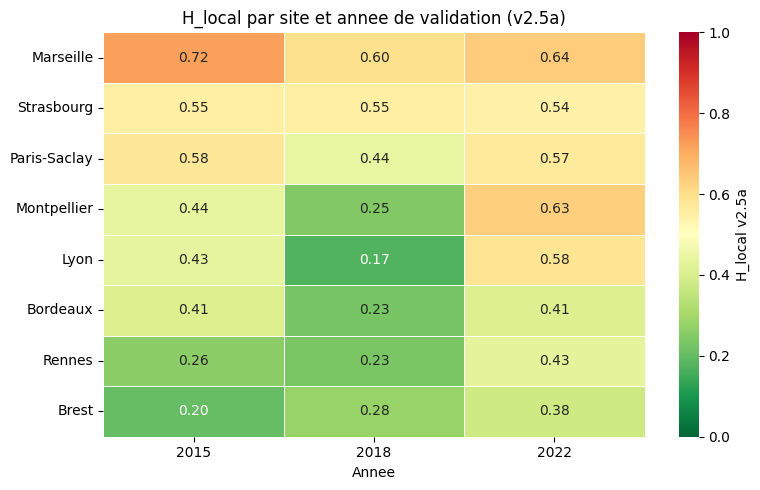

In [17]:
# Figure 1 : Heatmap
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn_r",
            vmin=0, vmax=1, cbar_kws={"label": "H_local v2.5a"},
            linewidths=0.5, linecolor="white", ax=ax)
ax.set_title("H_local par site et annee de validation (v2.5a)")
ax.set_xlabel("Annee"); ax.set_ylabel("")
plt.tight_layout()
plt.savefig("v4_fig_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

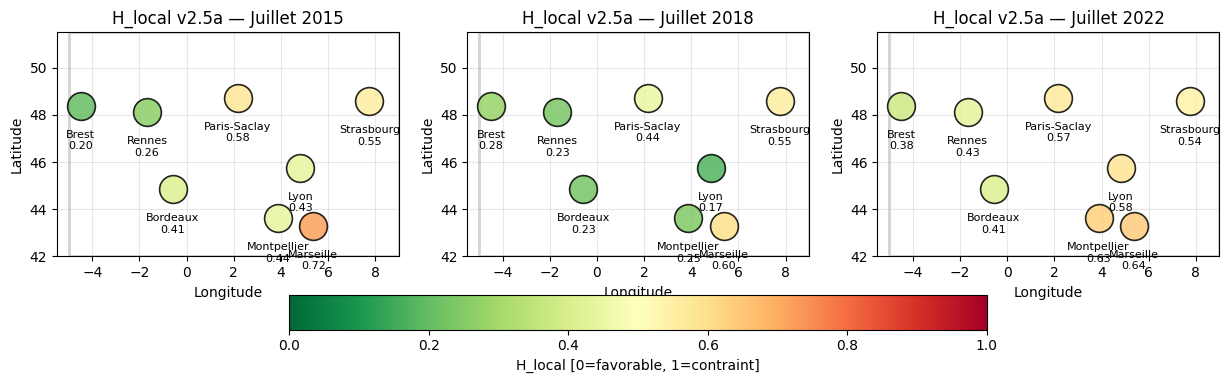

In [18]:
# Figure 2 : Carte de France
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, year in zip(axes, [2015, 2018, 2022]):
    sub = df_results[df_results["year"] == year].set_index("Site")
    ax.set_xlim(-5.5, 9); ax.set_ylim(42, 51.5)
    ax.set_aspect("equal")
    ax.add_patch(plt.Rectangle((-5, 42), 14, 9.5, fill=False,
                               edgecolor="lightgray", linewidth=2))
    for name, (lat, lon) in SITES.items():
        if name in sub.index:
            H = sub.loc[name, "H"]
            color = plt.cm.RdYlGn_r(H)
            ax.scatter(lon, lat, s=400, c=[color], edgecolors="black",
                       linewidths=1.2, alpha=0.85, zorder=3)
            ax.annotate(f"{name}\n{H:.2f}", (lon, lat),
                        fontsize=8, ha="center", va="center",
                        xytext=(0, -25), textcoords="offset points")
    ax.set_title(f"H_local v2.5a — Juillet {year}", fontsize=12)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.grid(alpha=0.3)
sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r, norm=plt.Normalize(0, 1))
sm.set_array([])
fig.colorbar(sm, ax=axes, orientation="horizontal", shrink=0.6,
             pad=0.1, label="H_local [0=favorable, 1=contraint]")
plt.savefig("v4_fig_carte_france.png", dpi=200, bbox_inches="tight")
plt.show()

/var/folders/1s/qxy7g5bd32x92pbdgm67xd0m0000gp/T/ipykernel_16601/125371375.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub.index, rotation=30, ha="right")
/var/folders/1s/qxy7g5bd32x92pbdgm67xd0m0000gp/T/ipykernel_16601/125371375.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub.index, rotation=30, ha="right")
/var/folders/1s/qxy7g5bd32x92pbdgm67xd0m0000gp/T/ipykernel_16601/125371375.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub.index, rotation=30, ha="right")


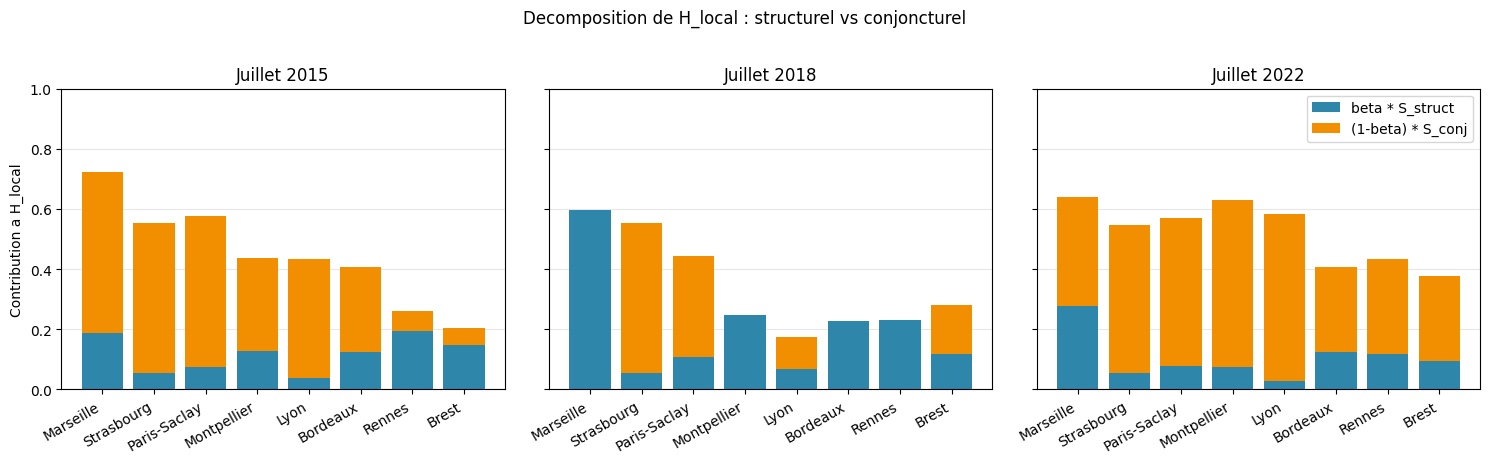

In [19]:
# Figure 3 : Decomposition empilee structurel/conjoncturel
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, year in zip(axes, [2015, 2018, 2022]):
    sub = df_results[df_results["year"] == year].set_index("Site").loc[sites_order]
    beta = sub["beta_t"].values
    contrib_struct = beta * sub["S_struct"].values
    contrib_conj   = (1 - beta) * sub["S_conj"].values
    ax.bar(sub.index, contrib_struct, label="beta * S_struct", color="#2E86AB")
    ax.bar(sub.index, contrib_conj, bottom=contrib_struct,
           label="(1-beta) * S_conj", color="#F18F01")
    ax.set_title(f"Juillet {year}")
    ax.set_xticklabels(sub.index, rotation=30, ha="right")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)
axes[0].set_ylabel("Contribution a H_local")
axes[2].legend(loc="upper right")
plt.suptitle("Decomposition de H_local : structurel vs conjoncturel", y=1.02)
plt.tight_layout()
plt.savefig("v4_fig_decomposition.png", dpi=200, bbox_inches="tight")
plt.show()

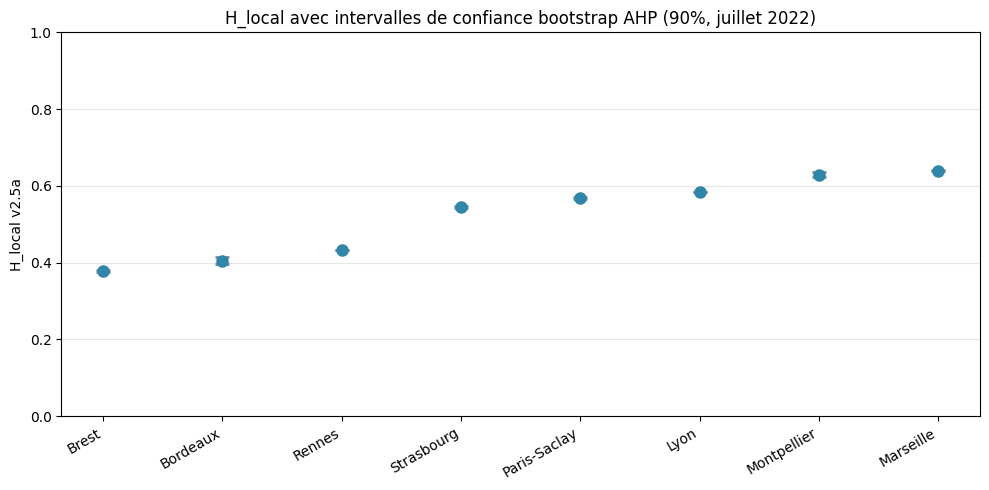

In [20]:
# Figure 4 : Distribution bootstrap H_local
fig, ax = plt.subplots(figsize=(10, 5))
sites_sorted = df_ic.sort_values("H_median")["Site"].tolist()
df_ic_s = df_ic.set_index("Site").loc[sites_sorted]

x = np.arange(len(sites_sorted))
ax.errorbar(x, df_ic_s["H_median"],
            yerr=[df_ic_s["H_median"] - df_ic_s["H_p5"],
                  df_ic_s["H_p95"] - df_ic_s["H_median"]],
            fmt="o", capsize=5, capthick=2, markersize=8,
            color="#2E86AB", ecolor="#888888")
ax.set_xticks(x); ax.set_xticklabels(sites_sorted, rotation=30, ha="right")
ax.set_ylabel("H_local v2.5a")
ax.set_title("H_local avec intervalles de confiance bootstrap AHP (90%, juillet 2022)")
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("v4_fig_bootstrap.png", dpi=200, bbox_inches="tight")
plt.show()

---
## 10. Synthese et limites

### Ce que H_local v2.5a fait

- **Ranking territorial** : ordonne 8 sites francais par contrainte hydrique structurelle + conjoncturelle.
- **Score absolu interpretable** : 0 = favorable, 1 = tres contraint.
- **Decomposition transparente** : chaque site sait pourquoi il a son score.
- **Sensibilite documentee** : Sobol + monotonicite + bootstrap AHP.

### Ce que H_local v2.5a ne fait PAS

- Pas de **prediction** d'incidents futurs.
- Pas de **calibration** sur observations (positionnement normatif).
- Pas de **transferabilite** automatique hors France metropolitaine.
- Pas de **validation forte** : Propluvia est un signal externe faible (n=8, p > 0.20).

### Architecture stratifiee

H_local n'est que la **couche 1** d'un cadre plus large :

```
H_local (FAIT)   ->  H_macro (futur)  ->  H_DC (futur)  ->  Score final
territoire           demande locale       besoin DC          decision site
```

### Cible de publication

- Acceptable : *Ecological Indicators*, *Sustainability*, *Water*.
- Avec extension a 50+ sites + Propluvia multi-annees : *Environmental Modelling & Software*.
- Hors de portee sans calibration empirique : *Nature Sustainability*.

### Prochaines etapes

1. Recuperer le raster SV (Seasonal Variability) Aqueduct.
2. Etendre a 96 prefectures francaises (significativite statistique).
3. Recuperer Propluvia 2017-2023 (validation multi-annees).
4. Developper H_macro et H_DC en couches additionnelles.

### Cles de l'engagement v2.5a

| Composante | Choix | Justification |
|---|---|---|
| Poids structurels | AHP (CR=0.0015) | rigoureux, documente |
| Agregation S_struct | arithmetique ponderee | meilleure concordance Propluvia (rho=0.52) |
| Combinaison SPEI | Boltzmann (tau=5) | empiriquement superieur au max dur |
| f(SPEI) | asymptotique c=2 | ancrage WMO (McKee 1993) |
| beta(t) | dynamique (1-S_conj) | bascule struct/conj automatique |

### Bibliographie cle

- Saaty, T. L. (1980). *The Analytic Hierarchy Process*. McGraw-Hill.
- Vicente-Serrano, S. M., Beguería, S., & López-Moreno, J. I. (2010). A multiscalar drought index sensitive to global warming: The Standardized Precipitation Evapotranspiration Index. *J. Climate*, 23(7), 1696-1718.
- Beguería, S., Vicente-Serrano, S. M., Reig, F., & Latorre, B. (2014). Standardized precipitation evapotranspiration index (SPEI) revisited. *Int. J. Climatology*, 34(10), 3001-3023.
- Nardo, M., et al. (2005). *Handbook on Constructing Composite Indicators*. OECD/JRC.
- Pfister, S., Koehler, A., & Hellweg, S. (2009). Assessing the environmental impacts of freshwater consumption in LCA. *Environ. Sci. Technol.*, 43(11), 4098-4104.
- Hofste, R. W., Reig, P., & Schleifer, L. (2019). *Aqueduct 3.0: Updated Decision-Relevant Global Water Risk Indicators*. WRI Tech. Note.
- Hersbach, H., et al. (2020). The ERA5 global reanalysis. *Quart. J. Roy. Meteorol. Soc.*, 146(730), 1999-2049.
- Saltelli, A., et al. (2010). Variance based sensitivity analysis of model output. *Computer Physics Communications*, 181(2), 259-270.
- Asadi, K., & Littman, M. L. (2017). An alternative softmax operator for reinforcement learning. *Proc. ICML*, 70, 243-252.

---

**Fin du notebook H_local v4**